<a href="https://colab.research.google.com/github/selcukkanun/DSA210-F1-LOGISTICS/blob/main/ML_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Project Objective**
The objective of this project is to investigate which measurable performance characteristics distinguish Formula 1 World Drivers’ Champions from non-champions. Rather than attempting to predict future championships or establish causal relationships, the analysis aims to identify statistical patterns associated with championship-level performance using regression and machine learning techniques.

##Methodology Overview
The analysis proceeds in three main stages. First, we construct a driver-level dataset summarizing career performance using race results, teammate comparisons, and wet-weather outcomes. Second, supervised learning models are employed to identify which performance features best separate champions from non-champions. Finally, unsupervised learning and probabilistic classification methods are used to explore performance archetypes and identify drivers with champion-like statistical profiles.


###Feature Engineering
To capture multiple dimensions of driver performance, four primary features were engineered:

- Teammate Beating Rate: The proportion of races in which a driver finished ahead of their teammate, measuring relative dominance within the same machinery.
- Total Races: A proxy for career longevity and experience.
- Wet-Weather Win Rate: The fraction of wet races won by a driver, capturing performance under difficult driving conditions.
- Wet-Weather Podiums: The total number of podium finishes in wet races, emphasizing consistency rather than rare peak performance.


To reduce noise arising from small sample sizes, the dataset was restricted to drivers with at least five wet-weather races and eight total career races.

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load preprocessed datasets

# Race-level results including wet-weather information
df_results = pd.read_csv("driver_finishing_positions.csv")

# Driver-level teammate beating statistics
df_beating = pd.read_csv("clean_teammate_beating_rate.csv")

# Construct wet-weather performance metrics
wet_races = df_results[df_results["is_true_wet"] == True]

wet_stats = wet_races.groupby("driverId").agg(
    wet_races_count=("raceId", "count"),
    wet_wins=("positionText", lambda x: (x == "1").sum()),
    wet_podiums=("positionText", lambda x: x.isin(["1", "2", "3"]).sum())
).reset_index()

wet_stats["wet_win_rate"] = wet_stats["wet_wins"] / wet_stats["wet_races_count"]

# Require at least 5 wet races for reliable estimates
wet_stats = wet_stats[wet_stats["wet_races_count"] >= 5]


## Merging Driver-Level Features

The wet-weather statistics are merged with previously computed teammate beating
rates to form a unified driver-level dataset. Drivers without sufficient wet
race data are assigned zero values to ensure numerical stability in machine
learning models.


In [5]:
# Merge datasets and create final ML table

df_ml = pd.merge(df_beating, wet_stats, on="driverId", how="left")
df_ml = df_ml.fillna(0)

# Create champion label
world_champions_list = [
    "Alain Prost", "Ayrton Senna", "Nigel Mansell", "Michael Schumacher",
    "Mika Hakkinen", "Damon Hill", "Jacques Villeneuve", "Fernando Alonso",
    "Kimi Raikkonen", "Jenson Button", "Sebastian Vettel", "Lewis Hamilton",
    "Nico Rosberg", "Max Verstappen", "Mika Häkkinen", "Kimi Räikkönen"
]

df_ml["full_name"] = df_ml["forename"] + " " + df_ml["surname"]
df_ml["is_champion"] = df_ml["full_name"].isin(world_champions_list).astype(int)

# Filter drivers with limited careers
df_ml_filtered = df_ml[df_ml["total_races"] >= 8].copy()

print(f"Drivers remaining after filtering: {len(df_ml_filtered)}")


Drivers remaining after filtering: 85


#Supervised Learning: Random Forest
A Random Forest classifier was trained to distinguish World Champions from non-champions using the engineered performance features. Feature importance analysis revealed that wet-weather podium finishes and teammate beating rate were the most informative variables, while total race count played a comparatively smaller role. This suggests that consistent high-level performance—particularly under challenging conditions—is more characteristic of champions than experience alone.

A Random Forest classifier was selected to distinguish World Champions from
non-champions due to its ability to model non-linear relationships and complex
feature interactions without strong parametric assumptions. Given the small and
imbalanced nature of the dataset, Random Forest offers greater robustness and
stability than standalone decision trees, while avoiding the rigidity of linear
models.

Importantly, the objective of this study is not predictive accuracy but the
identification of performance characteristics associated with championship-level
drivers. Random Forest supports this goal by enabling feature importance analysis
and capturing nuanced performance patterns, particularly under challenging
conditions such as wet races.


/tmp/ipython-input-2402268093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_model.feature_importances_, y=features, palette="viridis")


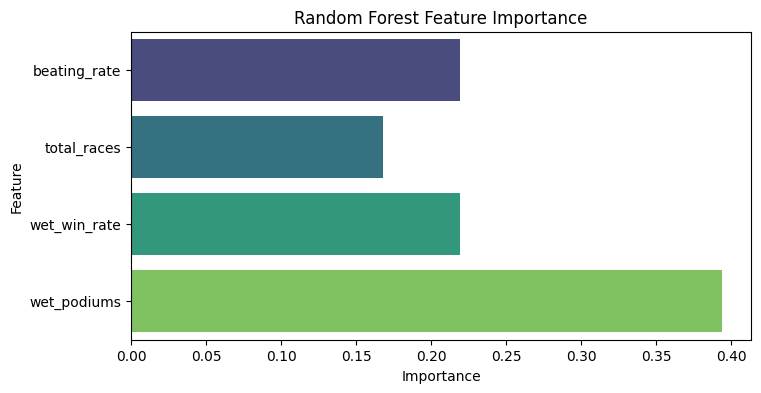

In [6]:
features = ["beating_rate", "total_races", "wet_win_rate", "wet_podiums"]
X = df_ml_filtered[features]
y = df_ml_filtered["is_champion"]

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)
rf_model.fit(X, y)

plt.figure(figsize=(8, 4))
sns.barplot(x=rf_model.feature_importances_, y=features, palette="viridis")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Unsupervised Learning: Clustering Driver Profiles

To explore whether drivers naturally group into performance archetypes, we apply
K-Means clustering to the standardized feature set without using championship
labels. This allows us to examine whether champions occupy distinct regions in
feature space.

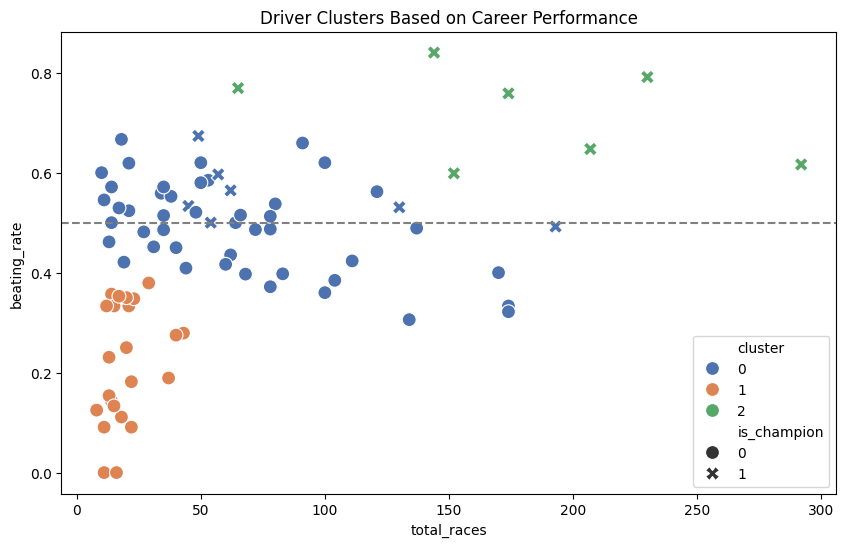

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ml_filtered["cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_ml_filtered,
    x="total_races",
    y="beating_rate",
    hue="cluster",
    style="is_champion",
    palette="deep",
    s=100
)
plt.axhline(0.5, linestyle="--", color="gray")
plt.title("Driver Clusters Based on Career Performance")
plt.show()


## Probabilistic Classification: Champion-Like Profiles

Finally, logistic regression is used to estimate the probability that a driver
belongs to the champion class given their performance profile. These probabilities
are interpreted as measures of similarity to historical champions rather than
predictions of future success.


In [13]:
log_reg = LogisticRegression()
log_reg.fit(X_scaled, y)
df_ml_filtered["champ_probability"] = log_reg.predict_proba(X_scaled)[:, 1]

outliers = (
    df_ml_filtered[df_ml_filtered["is_champion"] == 0]
    .sort_values("champ_probability", ascending=False)
)

print("Top non-champions with champion-like profiles:")
print(outliers[["full_name", "beating_rate", "wet_win_rate", "champ_probability"]].head(15))


Top non-champions with champion-like profiles:
                 full_name  beating_rate  wet_win_rate  champ_probability
21      Rubens Barrichello      0.305970      0.036364           0.302700
115           Sergio Pérez      0.321839      0.074074           0.277528
12            Felipe Massa      0.333333      0.057143           0.266161
83         Thierry Boutsen      0.666667      0.111111           0.260686
141           Lando Norris      0.659341      0.000000           0.251927
28      Juan Pablo Montoya      0.620000      0.111111           0.250584
42              Jean Alesi      0.552632      0.000000           0.248867
38   Heinz-Harald Frentzen      0.558824      0.035714           0.157555
117       Daniel Ricciardo      0.489051      0.040000           0.137035
139        Charles Leclerc      0.620000      0.000000           0.134463
8            Robert Kubica      0.584906      0.000000           0.128307
13         David Coulthard      0.360000      0.024390           

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print("F1-score:", f1_score(y_test, y_pred))



F1-score: 0.8


Classification Report:
              precision    recall  f1-score   support

Non-Champion       0.93      1.00      0.97        14
    Champion       1.00      0.67      0.80         3

    accuracy                           0.94        17
   macro avg       0.97      0.83      0.88        17
weighted avg       0.95      0.94      0.94        17



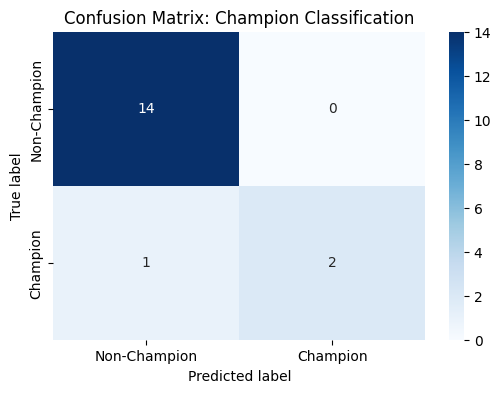

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Champion", "Champion"]
    )
)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Champion", "Champion"],
    yticklabels=["Non-Champion", "Champion"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix: Champion Classification")
plt.show()


The confusion matrix reveals that the model is highly conservative in identifying World Champions. All drivers predicted as champions are true champions, resulting in perfect precision for the champion class. However, one champion is misclassified as a non-champion, leading to a recall of 0.67.

This behavior indicates that the model prioritizes avoiding false positives over capturing all champions. Given the small number of champions and the coarse, career-level nature of the features, this trade-off is reasonable and suggests that championship-level performance profiles are distinctive but not uniform.

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)

coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": lin_reg.coef_
}).sort_values(by="coefficient", ascending=False)

print(coef_df)
r2 = lin_reg.score(X_scaled, y)
print("R²:", r2)


        feature  coefficient
3   wet_podiums     0.651592
2  wet_win_rate     0.539916
1   total_races     0.053573
0  beating_rate     0.000484
R²: 0.7541757217539331


The linear regression coefficients indicate that wet-weather performance,
particularly the number of wet-race podiums and wet win rate, is most strongly
associated with higher championship counts. In contrast, total career race count
exhibits only a weak relationship, suggesting that longevity alone is insufficient
to explain repeated championship success.

Interestingly, teammate beating rate shows a negligible association with the
number of championships won, indicating that while relative dominance may help
distinguish champions from non-champions, it does not scale linearly with the
extent of championship success.


##Why Linear Regression
Linear regression was employed to analyze the relationship between performance
characteristics and the number of World Championships won. Unlike the binary
classification setting, championship count is a continuous outcome, making
regression a more appropriate framework.

The purpose of this model is descriptive rather than predictive: regression
coefficients provide a transparent way to assess how different aspects of
driver performance scale with championship success. After standardizing the
features, the coefficients allow direct comparison of their relative importance.

By complementing the Random Forest classifier, linear regression helps distinguish
between features that merely separate champions from non-champions and those that
are associated with repeated championship dominance.


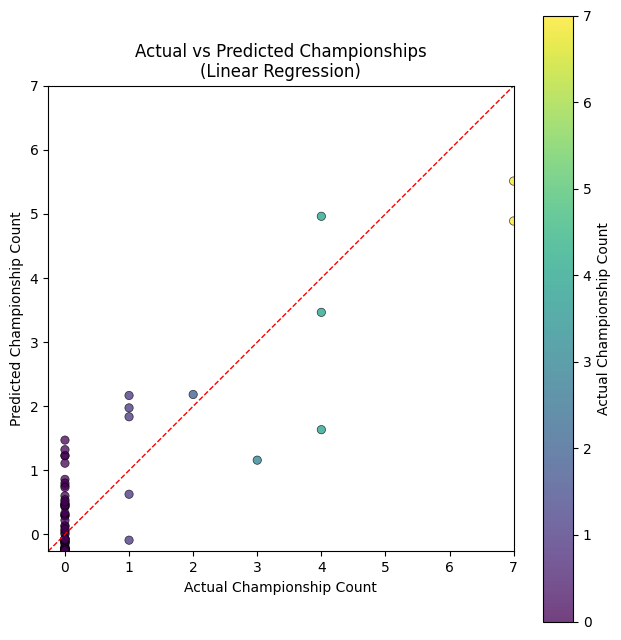

In [34]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6.5, 6.5))

scatter = plt.scatter(
    y,
    y_pred_lin,
    c=y,                 # color by actual championships
    cmap="viridis",
    alpha=0.75,
    edgecolor="black",
    linewidth=0.5
)

# Diagonal reference line
lims = [min(y.min(), y_pred_lin.min()), max(y.max(), y_pred_lin.max())]
plt.plot(lims, lims, linestyle="--", color="red", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Actual Championship Count")
plt.ylabel("Predicted Championship Count")
plt.title("Actual vs Predicted Championships\n(Linear Regression)")
cbar = plt.colorbar(scatter)
cbar.set_label("Actual Championship Count")

plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


The actual versus predicted championship count plot demonstrates that the model
captures a clear upward trend, with drivers who have won more championships
generally receiving higher predicted values. However, some other variables that can affect that chance are left out like constructors strength etc. which limits our model.

Accordingly, the regression is interpreted as descriptive rather than predictive.


#**Summary**
Overall, the analysis demonstrates that World Champions are statistically distinguished by sustained dominance over teammates and strong performance in wet-weather conditions. While the methods used do not establish causality or predict future championship outcomes, they provide meaningful insight into the performance profiles commonly associated with championship-level drivers.